In [165]:
from pathlib import Path

import matplotlib.pyplot as plt
import cv2
import numpy as np

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

THRESHOLD = 127


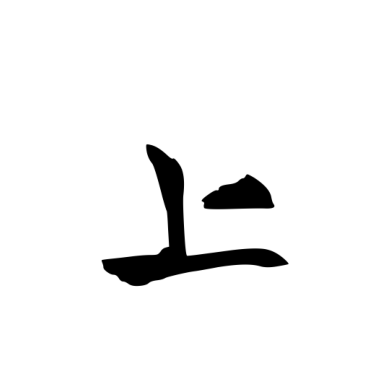

In [166]:
image_path = "../000-dataset/Longcang/4E0A.png"
THRESHOLD = 127
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()



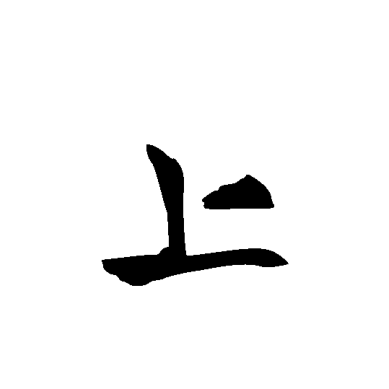

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(512, 512), dtype=uint8)

In [167]:
binary = cv2.threshold(image, THRESHOLD, 255, cv2.THRESH_BINARY)[1]
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

binary

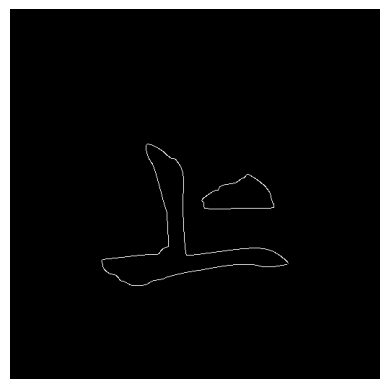

In [168]:
edge = cv2.Canny(binary, 100, 200)
plt.imshow(edge, cmap="gray")
plt.axis("off")
plt.show()

In [169]:
contours, hierarchy = cv2.findContours(edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for i, contour in enumerate(contours):
    print(
        i,
        contour.shape,
        cv2.contourArea(contour)
    )

0 (85, 1, 2) 3137.5
1 (548, 1, 2) 44.5


In [170]:
contour_image = np.ones(
    (512, 512, 3), dtype=np.uint8
) * 255

cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 0, 0),
    1
)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

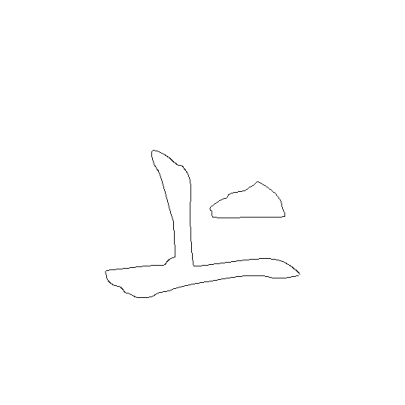

In [171]:
plt.figure(figsize=(5, 5))
plt.imshow(contour_image)
plt.axis("off")
plt.show()

In [172]:
longest_contour = max(
    contours,
    key=lambda x: len(x)
)

longest_contour.shape

(548, 1, 2)

In [173]:
contour1 = longest_contour[:, 0, :]

x, y = contour1[:, 0].astype(int), contour1[:, 1].astype(int)

print(x[:10])
print(y[:10])

[190 188 188 189 189 190 190 191 191 192]
[186 188 195 196 199 200 202 203 205 206]


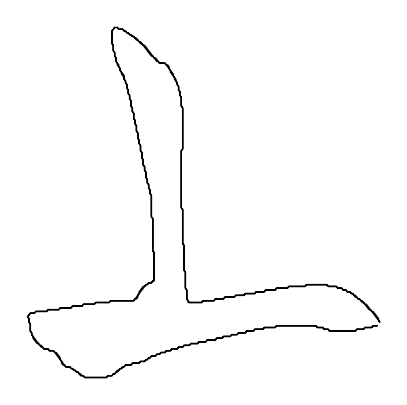

In [174]:
plt.figure(figsize=(5, 5))

plt.plot(x, y, color="black", linewidth=1)

plt.gca().invert_yaxis()

plt.axis("off")
plt.show()

In [175]:
dx, dy = np.gradient(x), np.gradient(y)
print(dx[:10])
print(dy[:10])

ddx, ddy = np.gradient(dx), np.gradient(dy)
print(ddx[:10])
print(ddy[:10])

[-2.  -1.   0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5]
[2.  4.5 4.  2.  2.  1.5 1.5 1.5 1.5 1. ]
[1.   1.25 0.75 0.   0.   0.   0.   0.   0.   0.25]
[ 2.5   1.   -1.25 -1.   -0.25 -0.25  0.    0.   -0.25  0.  ]


In [176]:
numerator = np.abs(
    dx * ddy - dy * ddx
)

denominator = (dx ** 2 + dy ** 2) ** 1.5

denominator[denominator < 1e-8] = 1e-8

curvature = numerator / denominator

print(curvature[:10])

[0.30935922 0.06763126 0.05533857 0.05706721 0.0142668  0.03162278
 0.         0.         0.03162278 0.17888544]


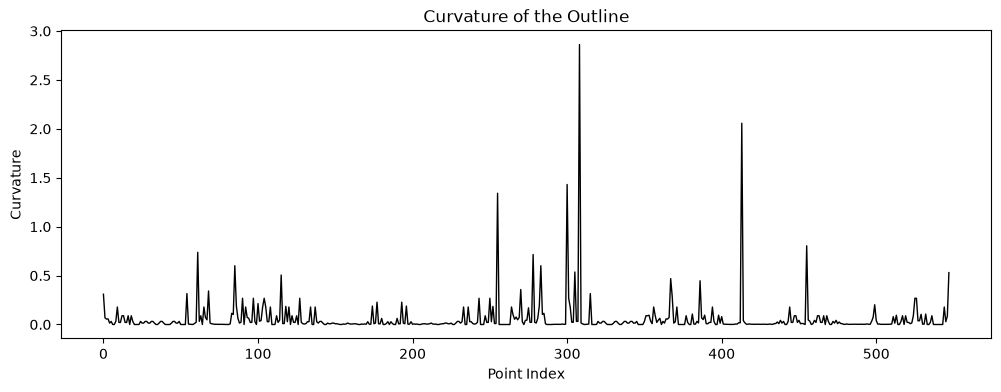

In [177]:
plt.figure(figsize=(12,4))

plt.plot(curvature, color="black", linewidth=1)
plt.xlabel("Point Index")
plt.ylabel("Curvature")
plt.title("Curvature of the Outline")
plt.show()

In [178]:
curvature_sum = np.sum(curvature)
print(f"Sum of curvature: {curvature_sum}")

Sum of curvature: 32.97314423602255


In [179]:
SIGMA = 1
smooth_curvature = gaussian_filter1d(
    curvature,
    sigma=SIGMA,
    mode="wrap"
)

peak, properties = find_peaks(
    smooth_curvature
)

print(peak[:10])
print(len(peak))

feature_points = contour1[peak]
print(feature_points[:10])



[ 9 12 16 18 28 31 37 46 54 61]
81
[[192 206]
 [194 210]
 [197 215]
 [198 217]
 [203 233]
 [205 238]
 [208 249]
 [212 266]
 [216 279]
 [217 329]]


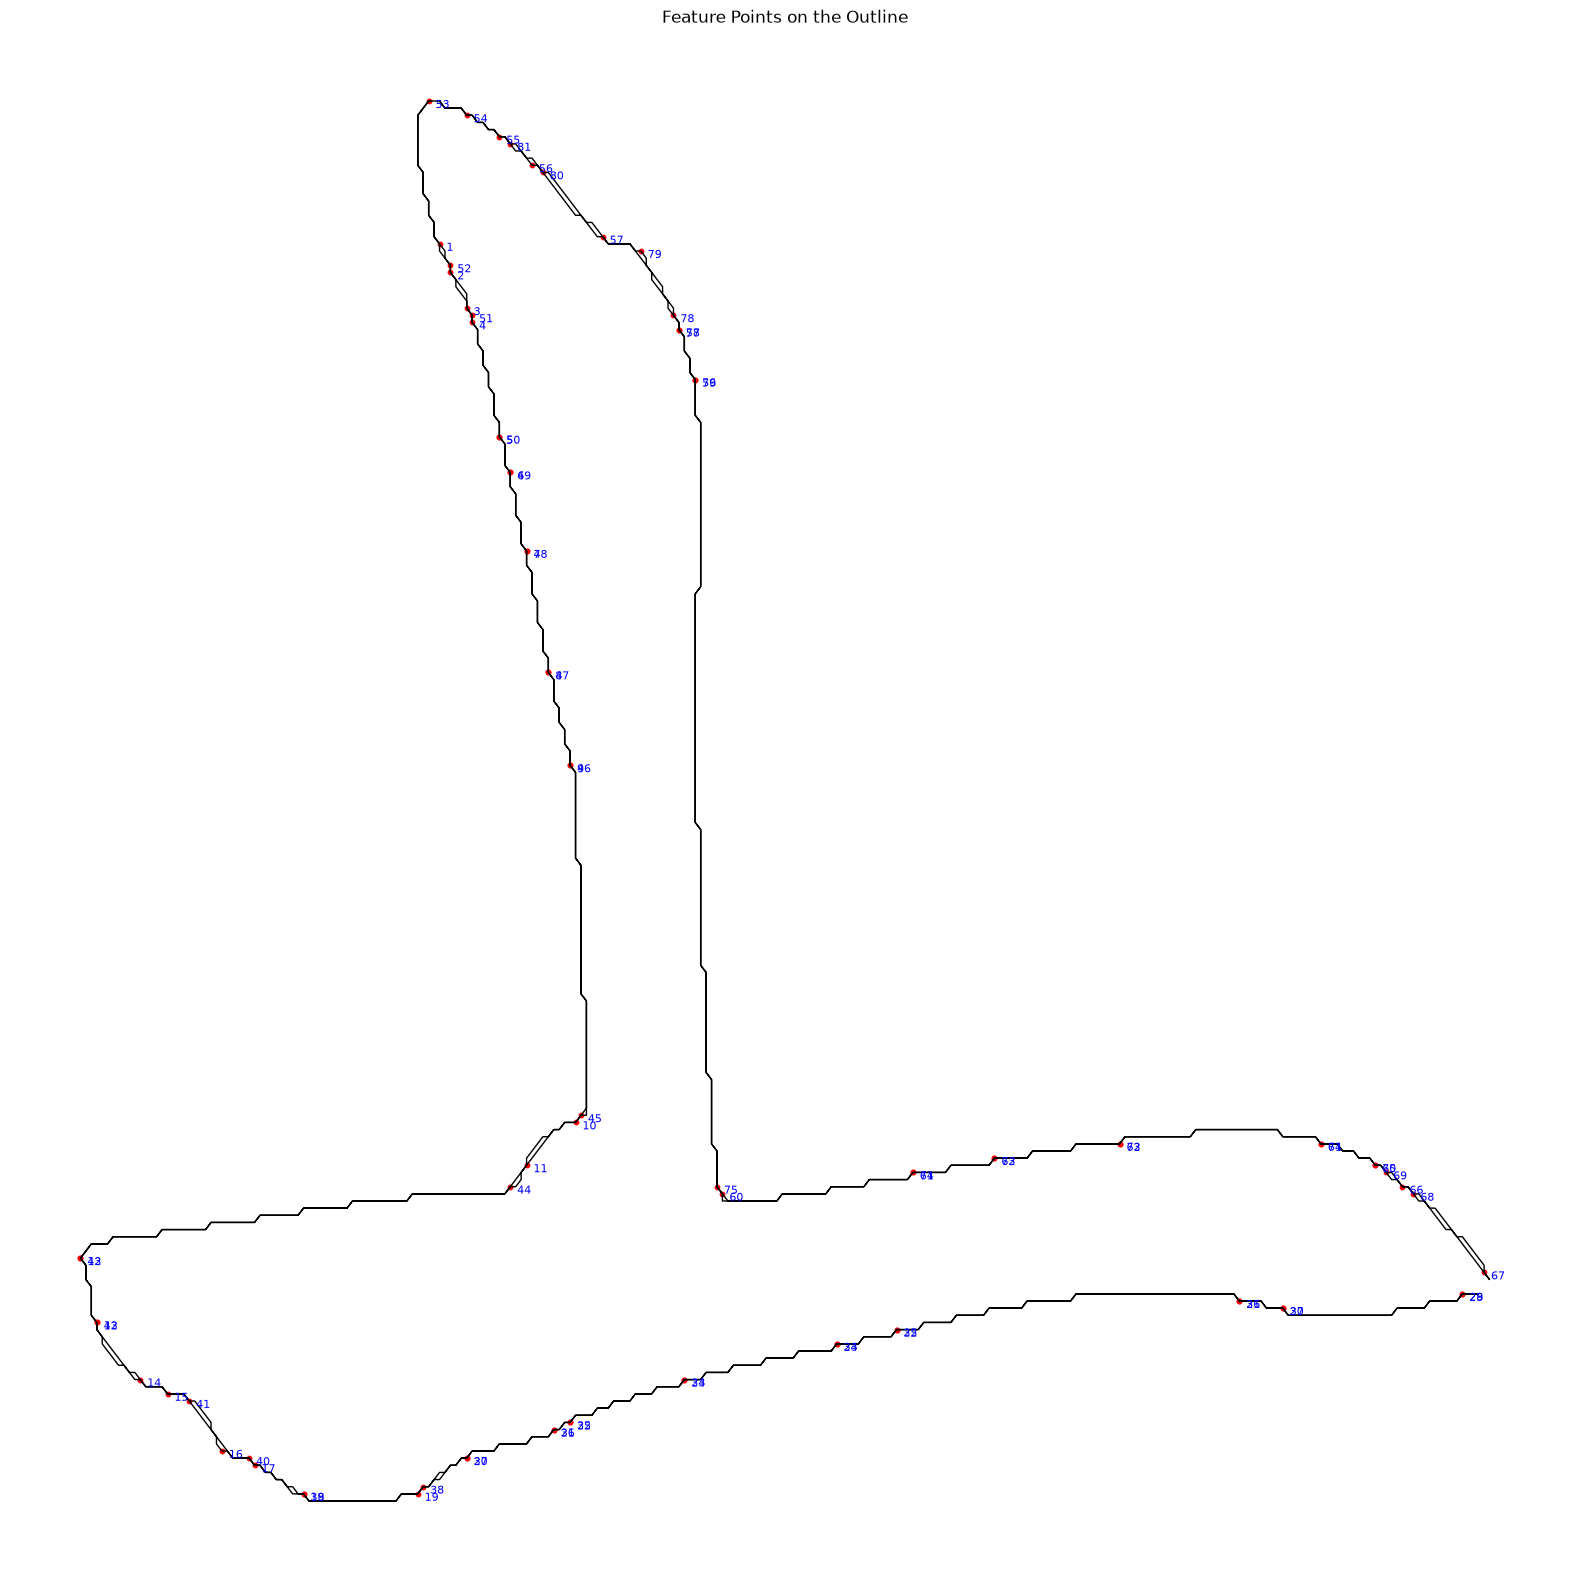

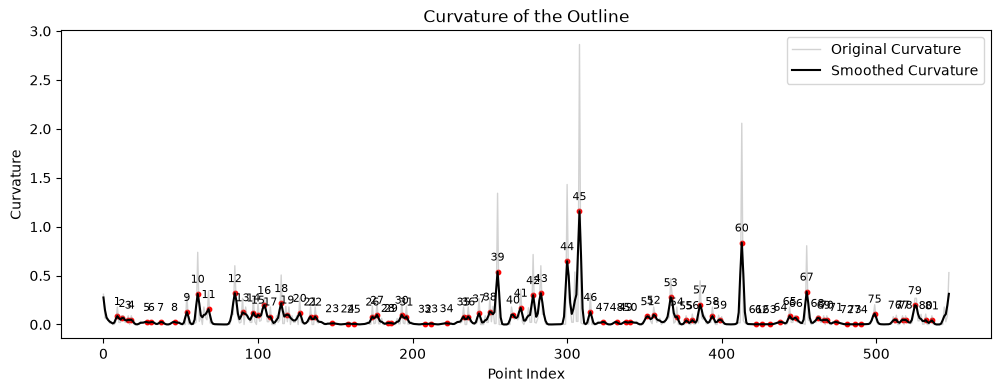

In [180]:
plt.figure(figsize=(20,20))

plt.plot(x, y, color="black", linewidth=1)

plt.scatter(
    feature_points[:, 0],
    feature_points[:, 1],
    color="red",
    s=10
)

for i, (fx, fy) in enumerate(feature_points):
    plt.annotate(
        f"{i+1}",
        xy=(fx, fy),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=8,
        color="blue"
    )

plt.gca().invert_yaxis()
plt.axis("off")
plt.title("Feature Points on the Outline")
plt.show()

plt.figure(figsize=(12, 4))

# 原始曲率：淡色
plt.plot(
    curvature,
    color="gray",
    linewidth=1,
    alpha=0.35,
    label="Original Curvature"
)

# Gaussian 平滑后的曲率：主线
plt.plot(
    smooth_curvature,
    color="black",
    linewidth=1.5,
    label="Smoothed Curvature"
)

for i, p in enumerate(peak):
    plt.scatter(
        p,
        smooth_curvature[p],
        color="red",
        s=10
    )
    plt.annotate(
        f"{i+1}",
        xy=(p, smooth_curvature[p]),
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=8,
        ha="center"
    )

plt.xlabel("Point Index")
plt.ylabel("Curvature")
plt.title("Curvature of the Outline")
plt.legend()
plt.show()

In [181]:
angles = []

for i in range(len(feature_points)):
    p1 = feature_points[i - 1]
    p2 = feature_points[i]
    p3 = feature_points[(i + 1) % len(feature_points)]

    v1 = p1 - p2
    v2 = p3 - p2

    numerator = np.dot(v1, v2)
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)
    denominator = np.clip(denominator, 1e-8, None)
    
    cos_angle = numerator / denominator
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    angles.append(np.degrees(angle))


angles = np.array(angles)
print(len(angles))
print(angles)

81
[110.55604522 175.60129465 175.60129465 170.78897346 175.55261515
 173.45370922 177.98540121 176.13779095 164.04303387 122.54430469
 155.31843622  80.57355492 153.43494882 156.80140949 163.14160123
 159.77514057 174.47245985 156.03751103 150.9453959  164.98163937
 175.60129465 177.51044708 174.17927575 179.81982519 173.32810427
 169.24203291 169.40675439  90.          90.         169.40675439
 169.24203291 173.32810427 179.81982519 174.17927575 177.51044708
 175.60129465 167.47119229 156.03751103 150.83238662 170.53767779
 176.87786954 141.34019175  78.77931322 149.64567001 125.23128617
 165.23457689 176.13779095 177.98540121 173.45370922 174.58813085
 166.64465904 160.12092565  64.18879716 169.38034472 172.87498365
 176.1214755  174.68968843 156.07749412 159.31277275  87.61227081
 177.30444909 177.37509736 175.03025927 163.30075577 165.7354877
 172.30394828   1.57655006 170.72739822 175.60129465 170.13419306
 163.30075577 175.03025927 177.37509736 175.58518675  88.84749258
 158.828

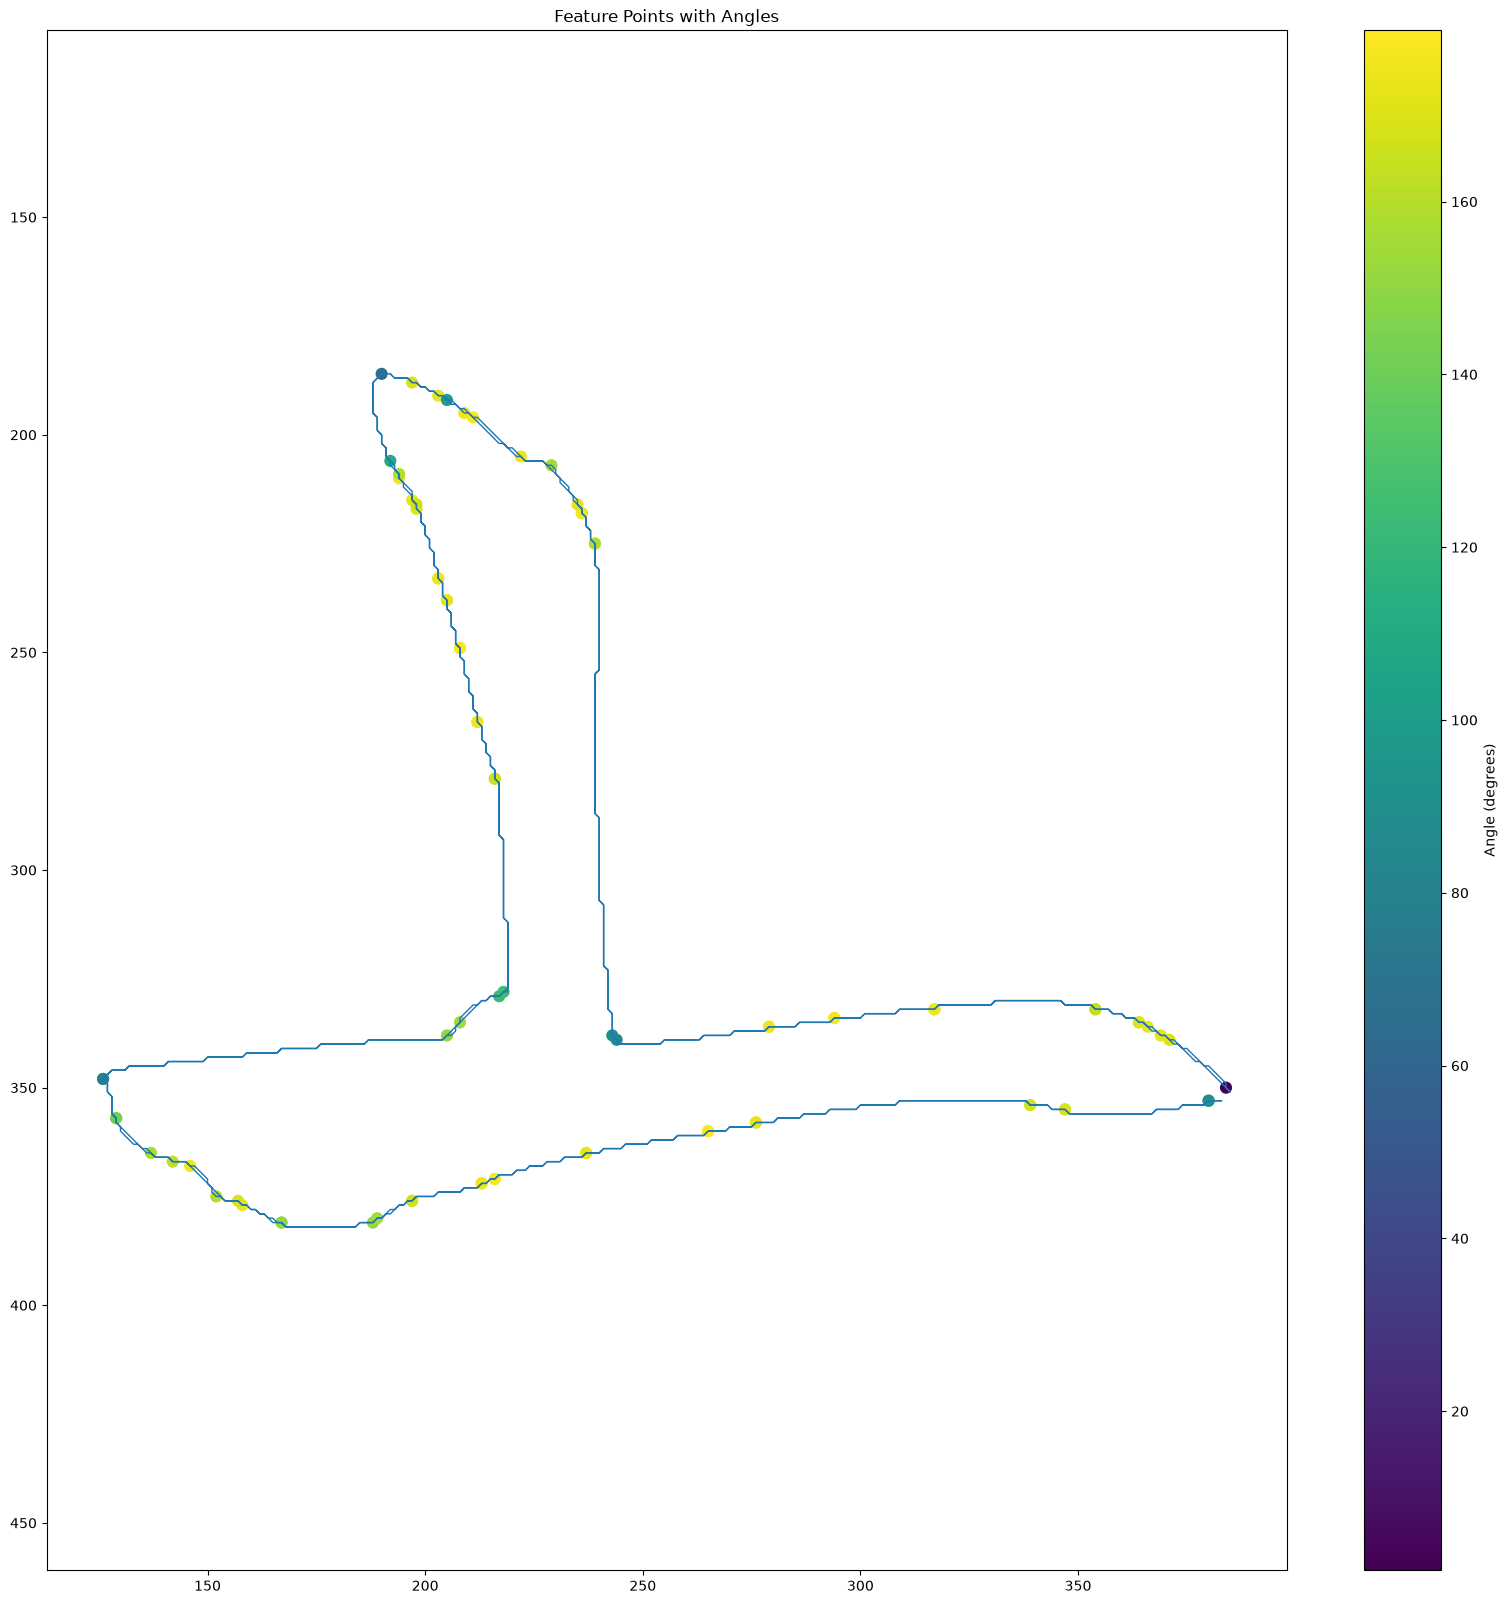

In [182]:
plt.figure(figsize=(20,20))

plt.plot(
    x, y,
    linewidth=1
)

scatter = plt.scatter(
    feature_points[:, 0],
    feature_points[:, 1],
    c=angles,
    s=60
)

plt.colorbar(
    scatter,
    label="Angle (degrees)"
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.title("Feature Points with Angles")
plt.show()

In [183]:
sorted_indeces = np.argsort(angles)

sorted_angles = angles[sorted_indeces]


print(sorted_angles[:10])

[  1.57655006  64.18879716  78.77931322  80.57355492  87.61227081
  88.84749258  90.          90.          99.18883608 110.55604522]


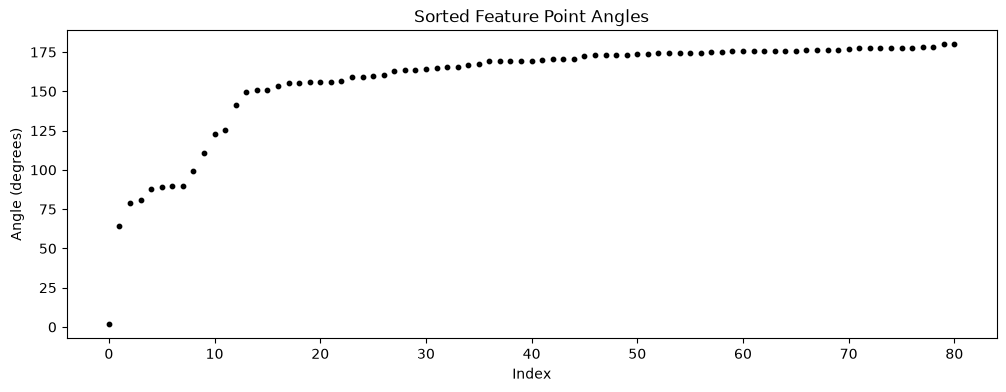

In [184]:
angle_x = np.arange(len(sorted_angles))

plt.figure(figsize=(12, 4))
plt.scatter(
    angle_x,
    sorted_angles,
    color="black",
    s=10
)
plt.xlabel("Index")
plt.ylabel("Angle (degrees)")
plt.title("Sorted Feature Point Angles")
plt.show()

In [185]:
x1, y1 = angle_x[0], sorted_angles[0]
x2, y2 = angle_x[-1], sorted_angles[-1]


principal_axis = (y1 +(y2-y1)/(x2-x1)*(angle_x-x1))
print(principal_axis[:10])

[ 1.57655006  3.80459099  6.03263193  8.26067287 10.48871381 12.71675475
 14.94479569 17.17283663 19.40087757 21.62891851]


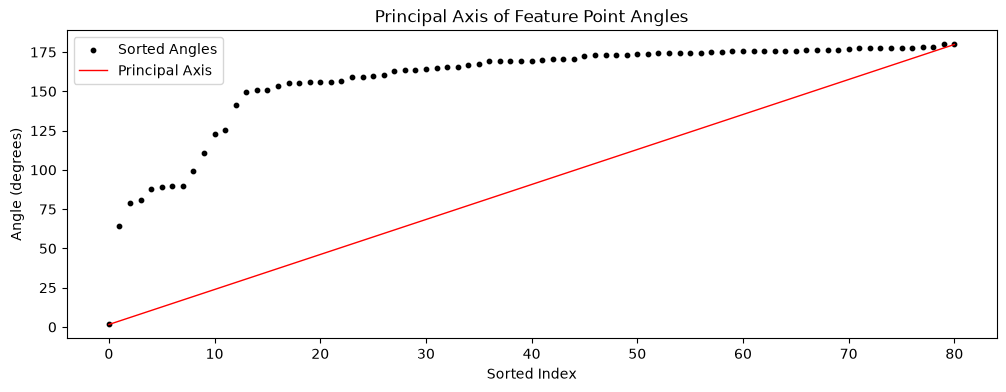

In [186]:
plt.figure(figsize=(12, 4))
plt.scatter(
    angle_x,
    sorted_angles,
    color="black",
    s=10,
    label="Sorted Angles"
)

plt.plot(
    angle_x,
    principal_axis,
    color="red",
    linewidth=1,
    label="Principal Axis"
)

plt.xlabel("Sorted Index")
plt.ylabel("Angle (degrees)")

plt.legend()
plt.title("Principal Axis of Feature Point Angles")
plt.show()

In [187]:
A = y2 - y1
B = x1 - x2
C = x2 * y1 - x1 * y2

distances = np.abs(A * angle_x + B * sorted_angles + C) / np.sqrt(A**2 + B**2)

print(distances[:10])

print(angle_x.shape)
print(distances.shape)

[ 0.         24.72569367 29.78779173 29.61016271 31.58000355 31.17347105
 30.73306926 29.82074696 32.67100366 36.41324502]
(81,)
(81,)


Text(0.5, 1.0, 'Distances of Feature Points to Principal Axis')

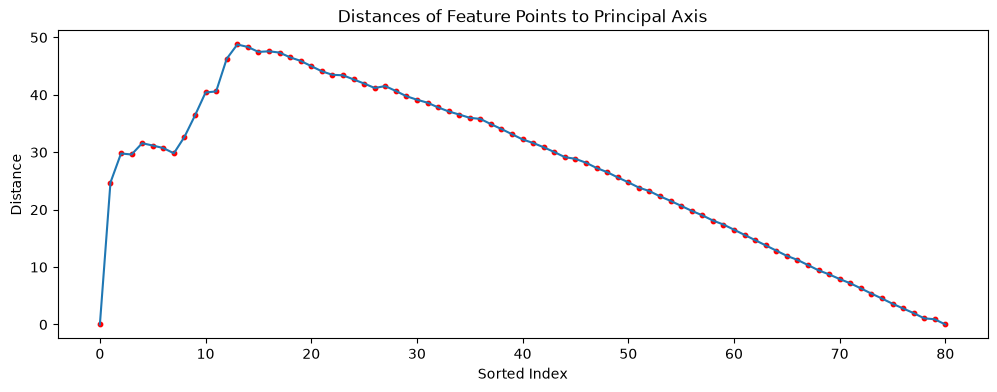

In [188]:
plt.figure(figsize=(12, 4))
plt.plot(
    angle_x,
    distances,
)
plt.scatter(
    angle_x,
    distances,
    color="red",
    s=10,
    label="Distances to Principal Axis"
) 

plt.xlabel("Sorted Index")
plt.ylabel("Distance")
plt.title("Distances of Feature Points to Principal Axis")

In [189]:
max_distance_index = np.argmax(distances)
max_distance = distances[max_distance_index]

print(f"Max distance: {max_distance} at index {max_distance_index}")

Max distance: 48.77009632917812 at index 13


In [190]:
angle_threshold = sorted_angles[max_distance_index]

print(f"Angle threshold: {angle_threshold}")

Angle threshold: 149.64567001037926


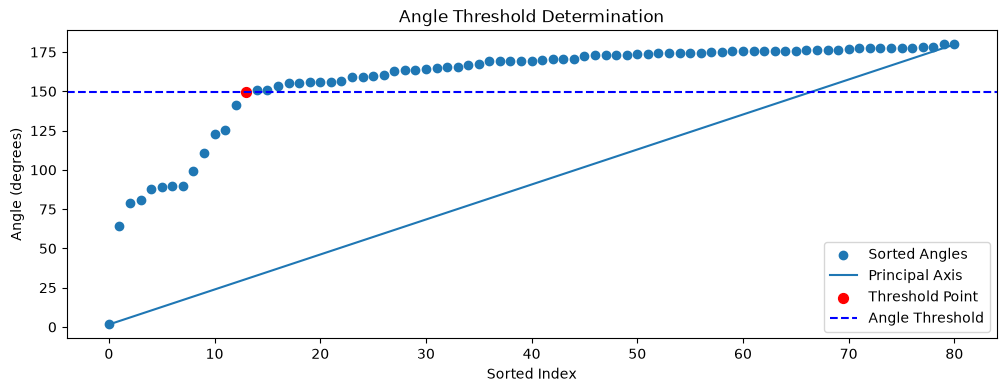

In [191]:
plt.figure(figsize=(12, 4))

plt.scatter(
    angle_x,
    sorted_angles,
    label="Sorted Angles"
)

plt.plot(
    angle_x,
    principal_axis,
    label="Principal Axis"
)

plt.scatter(
    max_distance_index,
    angle_threshold,
    s=50,
    color="red",
    label="Threshold Point"
)

plt.axhline(
    angle_threshold,
    linestyle="--",
    color="blue",
    label="Angle Threshold"
)

plt.xlabel("Sorted Index")
plt.ylabel("Angle (degrees)")

plt.legend()
plt.title("Angle Threshold Determination")
plt.show()

In [ ]:
final_mask = (angles < angle_threshold)
final_feature_points = feature_points[final_mask]

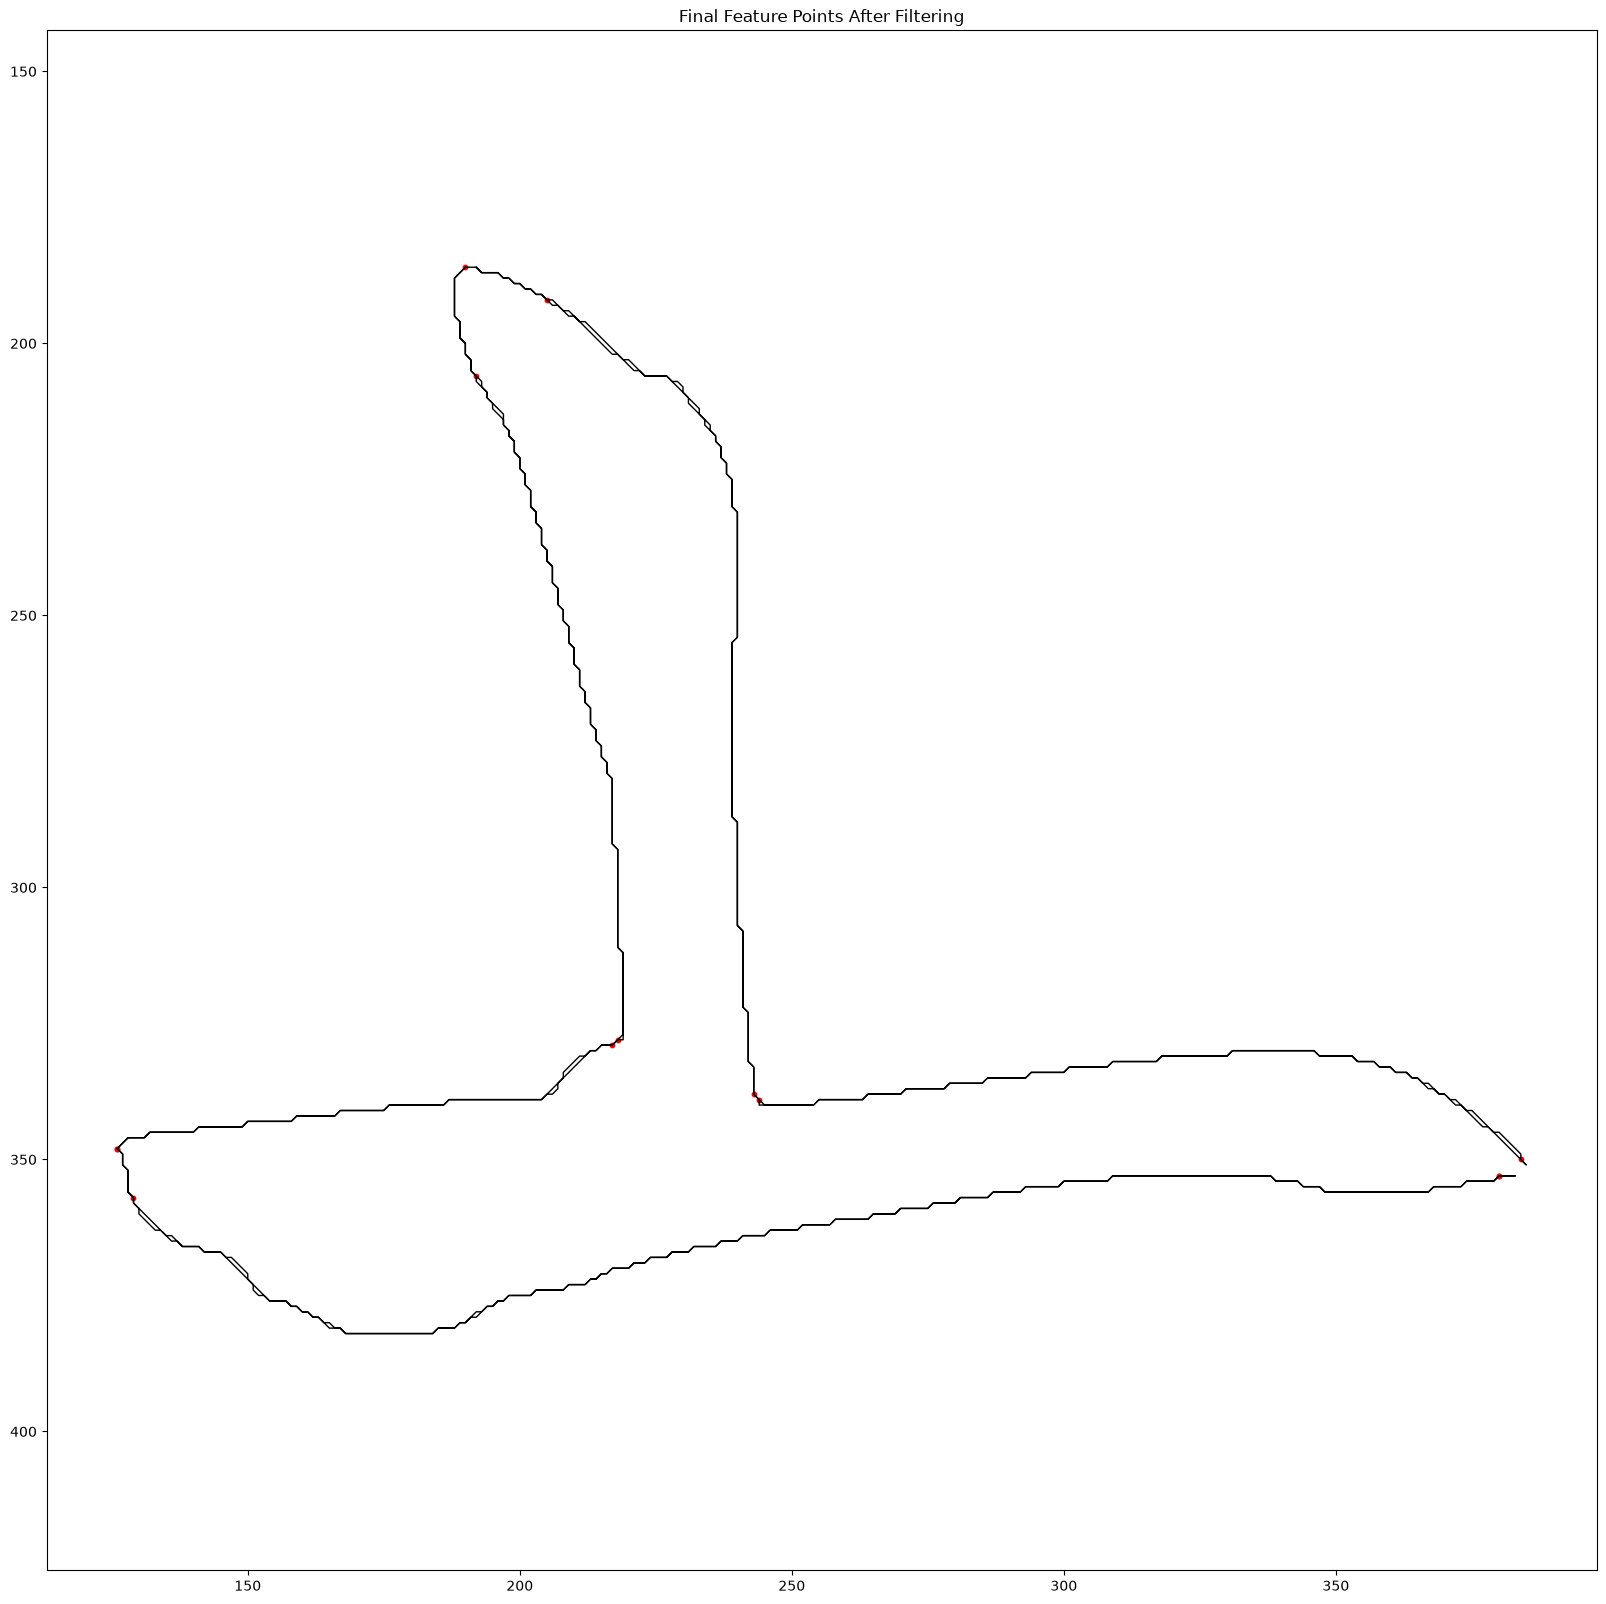

In [194]:
plt.figure(figsize=(20, 20))

plt.plot(x, y, color="black", linewidth=1)

plt.scatter(
    final_feature_points[:, 0],
    final_feature_points[:, 1],
    color="red",
    s=10
)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("Final Feature Points After Filtering")
plt.show()

In [195]:
final_peak_indices = peak[final_mask]

start_idx = final_peak_indices[0]
end_idx = final_peak_indices[-1]

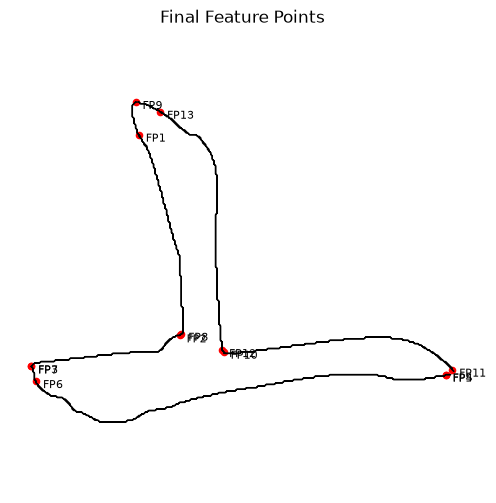

In [202]:
plt.figure(figsize=(6, 6))

plt.plot(
    x, y,
    color="black",
    linewidth=1
)

plt.scatter(
    contour1[final_peak_indices, 0],
    contour1[final_peak_indices, 1],
    color="red",
    s=20
)

for i, idx in enumerate(final_peak_indices):

    px = contour1[idx, 0]
    py = contour1[idx, 1]

    plt.annotate(
        f"FP{i+1}",
        xy=(px, py),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=8
    )

plt.gca().invert_yaxis()
plt.axis("equal")
plt.axis("off")

plt.title("Final Feature Points")

plt.show()